In [7]:
import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

In [8]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("paultimothymooney/chest-xray-pneumonia")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'chest-xray-pneumonia' dataset.
Path to dataset files: /kaggle/input/chest-xray-pneumonia


In [9]:

dataset_path = os.path.join(path, "chest_xray")

train_dir = os.path.join(dataset_path, "train")
val_dir = os.path.join(dataset_path, "val")
test_dir = os.path.join(dataset_path, "test")

print(train_dir)
print(val_dir)
print(test_dir)

/kaggle/input/chest-xray-pneumonia/chest_xray/train
/kaggle/input/chest-xray-pneumonia/chest_xray/val
/kaggle/input/chest-xray-pneumonia/chest_xray/test


In [10]:
import os

dataset_path = os.path.join(path, "chest_xray")

train_path = os.path.join(dataset_path, "train")
test_path = os.path.join(dataset_path, "test")
val_path = os.path.join(dataset_path, "val")




In [11]:
for root, dirs, files in os.walk(path):
    print(root)

/kaggle/input/chest-xray-pneumonia
/kaggle/input/chest-xray-pneumonia/chest_xray
/kaggle/input/chest-xray-pneumonia/chest_xray/chest_xray
/kaggle/input/chest-xray-pneumonia/chest_xray/chest_xray/val
/kaggle/input/chest-xray-pneumonia/chest_xray/chest_xray/val/PNEUMONIA
/kaggle/input/chest-xray-pneumonia/chest_xray/chest_xray/val/NORMAL
/kaggle/input/chest-xray-pneumonia/chest_xray/chest_xray/test
/kaggle/input/chest-xray-pneumonia/chest_xray/chest_xray/test/PNEUMONIA
/kaggle/input/chest-xray-pneumonia/chest_xray/chest_xray/test/NORMAL
/kaggle/input/chest-xray-pneumonia/chest_xray/chest_xray/train
/kaggle/input/chest-xray-pneumonia/chest_xray/chest_xray/train/PNEUMONIA
/kaggle/input/chest-xray-pneumonia/chest_xray/chest_xray/train/NORMAL
/kaggle/input/chest-xray-pneumonia/chest_xray/__MACOSX
/kaggle/input/chest-xray-pneumonia/chest_xray/__MACOSX/chest_xray
/kaggle/input/chest-xray-pneumonia/chest_xray/__MACOSX/chest_xray/val
/kaggle/input/chest-xray-pneumonia/chest_xray/__MACOSX/chest_x

In [12]:
print("Training")
print("NORMAL:", len(os.listdir(os.path.join(train_path, "NORMAL"))))
print("PNEUMONIA:", len(os.listdir(os.path.join(train_path, "PNEUMONIA"))))

print("\nTesting")
print("NORMAL:", len(os.listdir(os.path.join(test_path, "NORMAL"))))
print("PNEUMONIA:", len(os.listdir(os.path.join(test_path, "PNEUMONIA"))))

print("\nValidation")
print("NORMAL:", len(os.listdir(os.path.join(val_path, "NORMAL"))))
print("PNEUMONIA:", len(os.listdir(os.path.join(val_path, "PNEUMONIA"))))

Training
NORMAL: 1341
PNEUMONIA: 3875

Testing
NORMAL: 234
PNEUMONIA: 390

Validation
NORMAL: 8
PNEUMONIA: 8


In [13]:
IMG_SIZE = (150, 150)
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary'
)

validation_generator = test_datagen.flow_from_directory(
    val_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary'
)

test_generator = test_datagen.flow_from_directory(
    test_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)

Found 5216 images belonging to 2 classes.
Found 16 images belonging to 2 classes.
Found 624 images belonging to 2 classes.


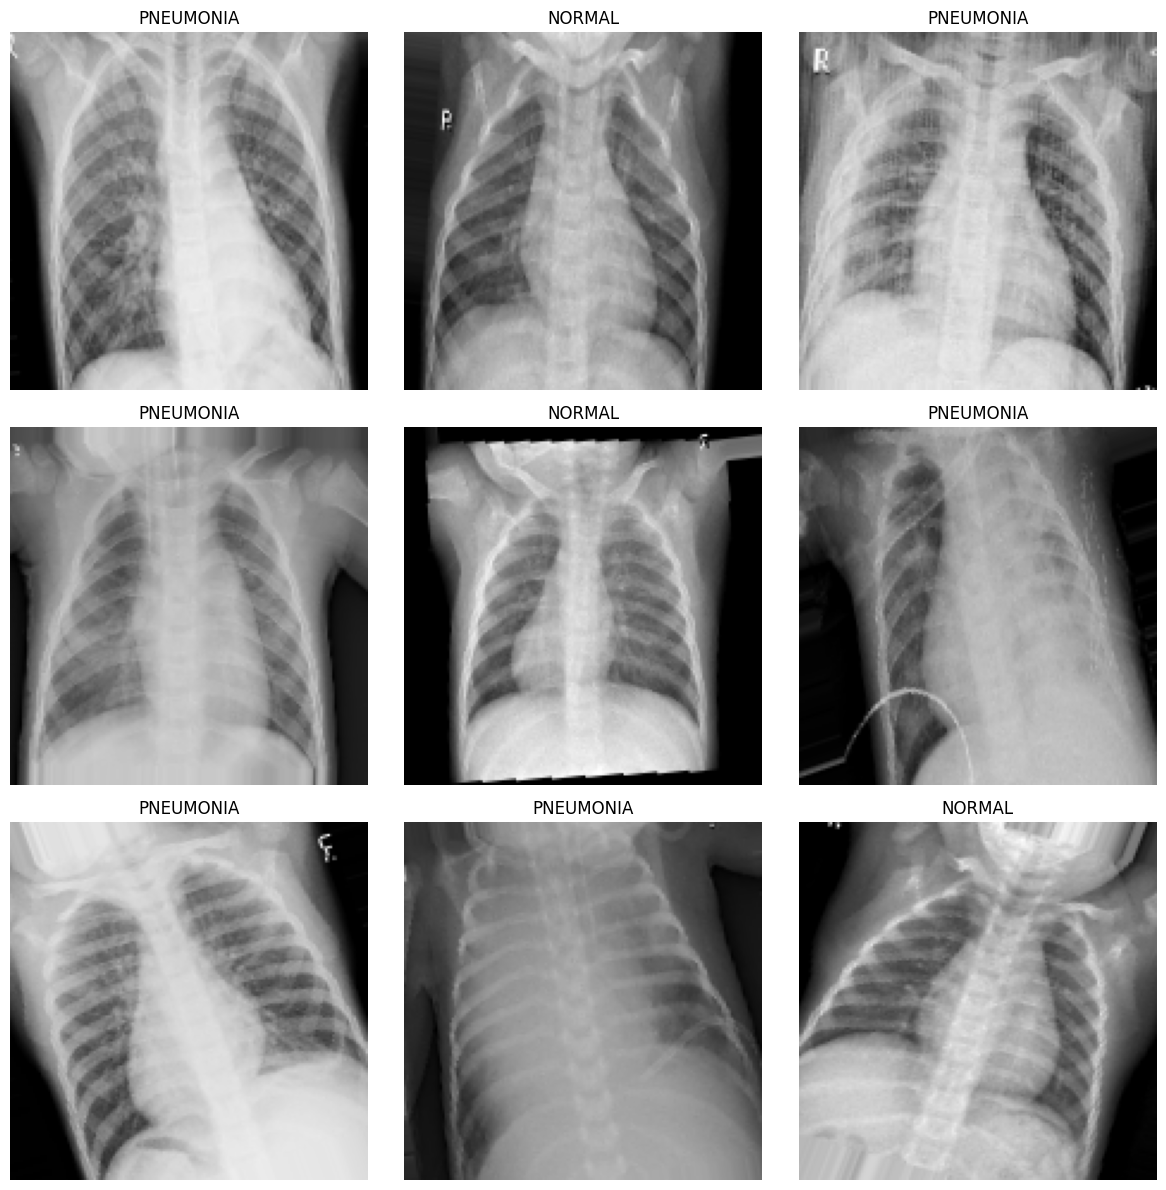

In [14]:
images, labels = next(train_generator)

plt.figure(figsize=(12,12))

for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(images[i])
    plt.title("PNEUMONIA" if labels[i] == 1 else "NORMAL")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [15]:
from tensorflow.keras.layers import BatchNormalization

model = Sequential([

    Conv2D(32, (3,3), activation='relu', input_shape=(150,150,3)),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Conv2D(256, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Flatten(),

    Dense(256, activation='relu'),
    Dropout(0.5),

    Dense(128, activation='relu'),
    Dropout(0.3),

    Dense(1, activation='sigmoid')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [16]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 148, 148, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 72, 72, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 34, 34, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 15, 15, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 15, 15, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 7, 7, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     3,211,520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,634,881 (13.87 MB)

 Trainable params: 3,633,921 (13.86 MB)

 Non-trainable params: 960 (3.75 KB)

In [17]:
history = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=10
)

Epoch 1/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 108s 594ms/step - accuracy: 0.8276 - loss: 0.5750 - val_accuracy: 0.5000 - val_loss: 17.0121
Epoch 2/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 82s 500ms/step - accuracy: 0.8779 - loss: 0.3017 - val_accuracy: 0.5000 - val_loss: 20.9143
Epoch 3/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 80s 489ms/step - accuracy: 0.8976 - loss: 0.2565 - val_accuracy: 0.5000 - val_loss: 11.7226
Epoch 4/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 79s 484ms/step - accuracy: 0.9089 - loss: 0.2530 - val_accuracy: 0.5000 - val_loss: 16.1585
Epoch 5/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 78s 482ms/step - accuracy: 0.9116 - loss: 0.2460 - val_accuracy: 0.5000 - val_loss: 20.6575
Epoch 6/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 79s 484ms/step - accuracy: 0.9176 - loss: 0.2154 - val_accuracy: 0.5000 - val_loss: 16.0535
Epoch 7/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 77s 473ms/step - accuracy: 0.9287 - loss: 0.1928 - val_accuracy: 0.5625 - val_loss: 5.5363
Epoch 8/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 77s 471ms/step - accuracy: 0.9388 - 

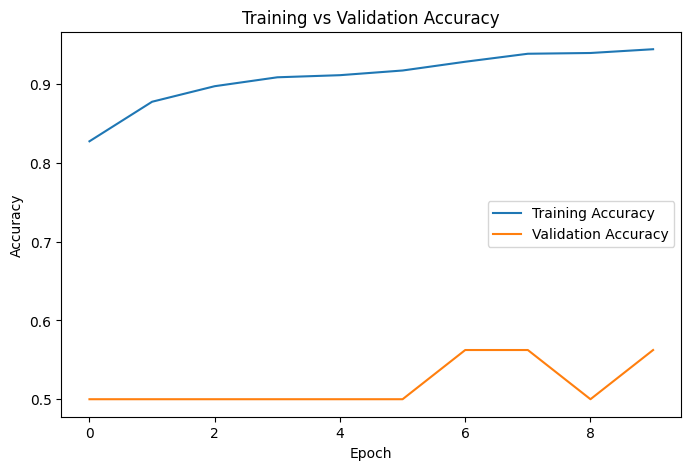

In [18]:
plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

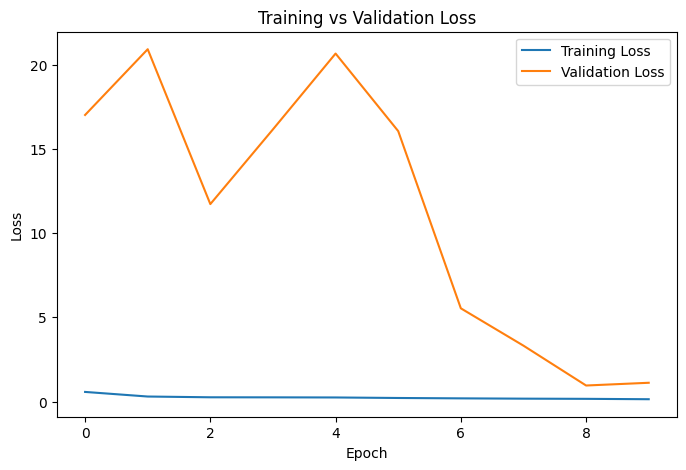

In [19]:
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

In [20]:
predictions = model.predict(test_generator)

predicted_classes = (predictions > 0.5).astype(int)

true_classes = test_generator.classes


20/20 ━━━━━━━━━━━━━━━━━━━━ 8s 312ms/step


In [21]:
print(classification_report(
    true_classes,
    predicted_classes,
    target_names=["NORMAL","PNEUMONIA"]
))

              precision    recall  f1-score   support

      NORMAL       0.98      0.55      0.70       234
   PNEUMONIA       0.78      0.99      0.88       390

    accuracy                           0.83       624
   macro avg       0.88      0.77      0.79       624
weighted avg       0.86      0.83      0.81       624



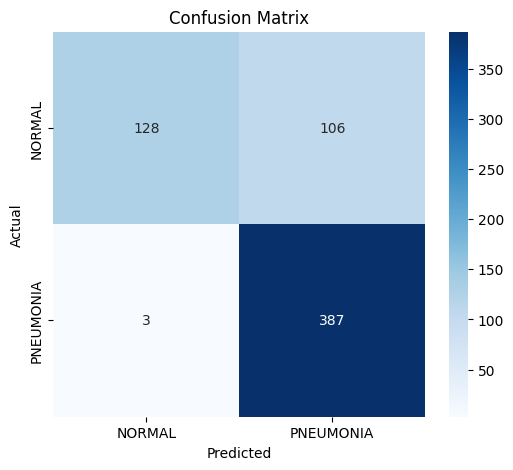

In [22]:
cm = confusion_matrix(true_classes, predicted_classes)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=["NORMAL","PNEUMONIA"],
    yticklabels=["NORMAL","PNEUMONIA"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 955ms/step
Prediction : PNEUMONIA


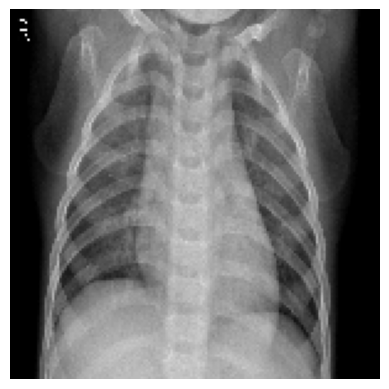

In [23]:
from tensorflow.keras.preprocessing import image
import numpy as np

sample_image = os.path.join(test_path, "NORMAL", os.listdir(os.path.join(test_path, "NORMAL"))[0])

img = image.load_img(sample_image, target_size=(150,150))

img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)
img_array = img_array / 255.0

prediction = model.predict(img_array)

plt.imshow(img)
plt.axis("off")

if prediction[0][0] > 0.5:
    print("Prediction : PNEUMONIA")
else:
    print("Prediction : NORMAL")

In [24]:
model.save("Pneumonia_CNN_Model.keras")

print("Model saved successfully!")

Model saved successfully!
